In [10]:
# training_ai.ipynb (PHIÊN BẢN SỬA LỖI CHO JUPYTER NOTEBOOK)

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import warnings
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# =============================================================================
# SECTION 1: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU GỐC
# =============================================================================
print("--- Bắt đầu quá trình huấn luyện ---")
print("1. Đang đọc và làm sạch dữ liệu...")

df = pd.read_csv('vietnam_housing_dataset - Copy.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# <<<--- BƯỚC MỚI QUAN TRỌNG: CHUẨN HÓA CÁC CỘT CATEGORY DỰA TRÊN DỮ LIỆU THỰC TẾ --->>>
print("1.1. Đang chuẩn hóa giá trị các cột category...")

def standardize_legal_status(series):
    """Chuẩn hóa cột legal_status một cách bao quát."""
    # Chuyển tất cả về dạng chữ thường để dễ xử lý
    s_lower = series.str.lower().fillna('không xác định')
    
    # Tạo điều kiện cho từng loại
    cond_so_hong = s_lower.str.contains('certificate|sổ hồng|sổ đỏ', na=False)
    cond_hop_dong = s_lower.str.contains('contract|hợp đồng', na=False)
    cond_cho_so = s_lower.str.contains('chờ sổ', na=False)
    
    # Áp dụng điều kiện
    return np.select(
        [cond_so_hong, cond_hop_dong, cond_cho_so],
        ['Sổ hồng/Sổ đỏ', 'Hợp đồng', 'Đang chờ sổ'],
        default='Khác'
    )

def standardize_furniture_state(series):
    """Chuẩn hóa cột furniture_state."""
    s_lower = series.str.lower().fillna('không xác định')
    
    cond_day_du = s_lower.str.contains('full|đầy đủ|cao cấp', na=False)
    cond_co_ban = s_lower.str.contains('basic|cơ bản|wall-mounted', na=False)
    cond_khong_noi_that = s_lower.str.contains('none|không nội thất', na=False)
    
    return np.select(
        [cond_day_du, cond_co_ban, cond_khong_noi_that],
        ['Nội thất đầy đủ', 'Nội thất cơ bản', 'Không nội thất'],
        default='Khác'
    )

if 'legal_status' in df.columns:
    df['legal_status'] = standardize_legal_status(df['legal_status'])
    print("\n   Phân bố legal_status sau chuẩn hóa:")
    print(df['legal_status'].value_counts())

if 'furniture_state' in df.columns:
    df['furniture_state'] = standardize_furniture_state(df['furniture_state'])
    print("\n   Phân bố furniture_state sau chuẩn hóa:")
    print(df['furniture_state'].value_counts())


# (Phần xử lý outliers giữ nguyên như cũ)
numerical_cols_base = ['price', 'area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
for col in numerical_cols_base:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['price', 'area']); df = df[(df['price'] > 0) & (df['area'] > 0)]
df['price_per_m2'] = df['price'] / df['area']
lower_bound, upper_bound = df['price_per_m2'].quantile([0.02, 0.98])
df = df[(df['price_per_m2'] >= lower_bound) & (df['price_per_m2'] <= upper_bound)]
df = df.drop(columns=['price_per_m2'])
print(f"\n    => Shape sau khi lọc outliers: {df.shape}")

# =============================================================================
# SECTION 2: HÀM TRÍCH XUẤT ĐỊA CHỈ NÂNG CẤP (V4)
# =============================================================================
print("\n2. Đang trích xuất City/District bằng hàm V4 (ưu tiên Quận/Huyện)...")

def extract_district_city_v4(address):
    if pd.isna(address) or not isinstance(address, str) or not address.strip():
        return 'Other', 'Other'
    addr = address.lower().replace('.', '')
    parts = [p.strip() for p in addr.split(',')]
    city_map = {'hà nội': 'HN', 'hồ chí minh': 'HCM', 'tp hcm': 'HCM', 'tphcm': 'HCM', 'sài gòn': 'HCM', 'hải phòng': 'HP', 'đà nẵng': 'ĐN', 'cần thơ': 'CT', 'bình dương': 'BD', 'đồng nai': 'Đồng Nai', 'bà rịa vũng tàu': 'BRVT', 'khánh hòa': 'KH', 'long an': 'LA', 'hưng yên': 'HY', 'an giang': 'An Giang', 'bắc giang': 'Bắc Giang', 'bắc kạn': 'Bắc Kạn', 'bạc liêu': 'Bạc Liêu', 'bắc ninh': 'Bắc Ninh', 'bến tre': 'Bến Tre', 'bình định': 'Bình Định', 'bình phước': 'Bình Phước', 'bình thuận': 'Bình Thuận', 'cà mau': 'Cà Mau', 'cao bằng': 'Cao Bằng', 'đắk lắk': 'Đắk Lắk', 'đắk nông': 'Đắk Nông', 'điện biên': 'Điện Biên', 'gia lai': 'Gia Lai', 'hà giang': 'Hà Giang', 'hà nam': 'Hà Nam', 'hà tĩnh': 'Hà Tĩnh', 'hải dương': 'Hải Dương', 'hậu giang': 'Hậu Giang', 'hòa bình': 'Hòa Bình', 'kiên giang': 'Kiên Giang', 'kon tum': 'Kon Tum', 'lai châu': 'Lai Châu', 'lâm đồng': 'Lâm Đồng', 'lạng sơn': 'Lạng Sơn', 'lào cai': 'Lào Cai', 'nam định': 'Nam Định', 'nghệ an': 'Nghệ An', 'ninh bình': 'Ninh Bình', 'ninh thuận': 'Ninh Thuận', 'phú thọ': 'Phú Thọ', 'phú yên': 'Phú Yên', 'quảng bình': 'Quảng Bình', 'quảng nam': 'Quảng Nam', 'quảng ngãi': 'Quảng Ngãi', 'quảng ninh': 'Quảng Ninh', 'quảng trị': 'Quảng Trị', 'sóc trăng': 'Sóc Trăng', 'sơn la': 'Sơn La', 'tây ninh': 'Tây Ninh', 'thái bình': 'Thái Bình', 'thái nguyên': 'Thái Nguyên', 'thanh hóa': 'Thanh Hóa', 'thừa thiên huế': 'Thừa Thiên Huế', 'huế': 'Thừa Thiên Huế', 'tiền giang': 'Tiền Giang', 'trà vinh': 'Trà Vinh', 'tuyên quang': 'Tuyên Quang', 'vĩnh long': 'Vĩnh Long', 'vĩnh phúc': 'Vĩnh Phúc', 'yên bái': 'Yên Bái'}
    found_city, found_district = 'Other', 'Other'
    district_keywords = ['quận', 'huyện', 'thị xã', 'thành phố', 'tp']
    for part in reversed(parts):
        if any(keyword in part for keyword in district_keywords) and not any(city_name in part for city_name in ['hà nội', 'hồ chí minh', 'hải phòng', 'đà nẵng', 'cần thơ']):
            for kw in district_keywords: part = part.replace(kw, '').strip()
            found_district = part.title(); break
    for part in reversed(parts):
        for name, code in city_map.items():
            if name in part: found_city = code; break
        if found_city != 'Other': break
    return found_city, found_district

address_col_name = 'address'
df['city'], df['district'] = zip(*df[address_col_name].apply(extract_district_city_v4))
df = df.drop(address_col_name, axis=1, errors='ignore')
df['log_price'] = np.log1p(df['price'])

print("\n    => Phân bố District sau khi sửa lỗi (V4):")
print(df['district'].value_counts().head(20))

# =============================================================================
# SECTION 3: CHUẨN BỊ DỮ LIỆU VÀ FEATURE ENGINEERING
# =============================================================================
print("3. Đang chuẩn bị dữ liệu và tạo các features...")

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)
print(f"    => Kích thước Train: {len(train_df):,} | Test: {len(test_df):,}")

numerical_cols = ['area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
district_medians = {col: train_df.groupby('district')[col].median().to_dict() for col in numerical_cols}
overall_medians = {col: train_df[col].median() for col in numerical_cols}

train_df_temp = train_df.copy()
train_df_temp['price_per_m2_temp'] = train_df_temp['price'] / train_df_temp['area']
district_avg = train_df_temp.groupby('district')['price_per_m2_temp'].mean().to_dict()
overall_avg = train_df_temp['price_per_m2_temp'].mean()
del train_df_temp

good_dirs = ['Nam', 'Đông - Nam', 'Đông', 'Đông Nam']
cat_cols = ['house_direction', 'legal_status', 'furniture_state', 'city', 'district']

def create_features(d):
    df_copy = d.copy()
    for col in numerical_cols:
        if col in df_copy.columns:
            df_copy[col] = df_copy.apply(
                lambda row: district_medians[col].get(row['district'], overall_medians[col]) if pd.isna(row[col]) else row[col],
                axis=1
            )
    for col in cat_cols:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].fillna('Missing').astype(str)
    df_copy['district_avg_price_per_m2'] = df_copy['district'].map(district_avg).fillna(overall_avg)
    df_copy['total_rooms'] = df_copy.get('bedrooms', 0).fillna(0) + df_copy.get('bathrooms', 0).fillna(0) + 1
    df_copy['bed_bath_ratio'] = df_copy.get('bedrooms', 0).fillna(0) / (df_copy.get('bathrooms', 0).fillna(0) + 1e-6)
    df_copy['area_per_floor'] = df_copy.get('area', 1).fillna(1) / (df_copy.get('floors', 1).fillna(1) + 1e-6)
    df_copy['rooms_per_floor'] = df_copy['total_rooms'] / (df_copy.get('floors', 1).fillna(1) + 1e-6)
    df_copy['is_good_direction'] = df_copy.get('house_direction', '').isin(good_dirs).astype(int)
    df_copy['area_x_district_avg'] = df_copy.get('area', 0).fillna(0) * df_copy['district_avg_price_per_m2']
    df_copy['frontage_x_access'] = df_copy.get('frontage', 0).fillna(0) * df_copy.get('access_road', 0).fillna(0)
    return df_copy

train_df = create_features(train_df)
test_df = create_features(test_df)

# =============================================================================
# SECTION 4: HUẤN LUYỆN MODEL CATBOOST
# =============================================================================
print("4. Bắt đầu huấn luyện model CatBoost...")

features = [
    'area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms',
    'total_rooms', 'bed_bath_ratio', 'area_per_floor', 'rooms_per_floor',
    'is_good_direction', 'district_avg_price_per_m2',
    'area_x_district_avg', 'frontage_x_access',
    'house_direction', 'legal_status', 'furniture_state', 'city', 'district'
]
features = [f for f in features if f in train_df.columns]
cat_cols = [c for c in cat_cols if c in features]

X_train = train_df[features]
y_train = train_df['log_price']
X_test = test_df[features]
y_test = test_df['log_price']

model = CatBoostRegressor(
    iterations=7000, learning_rate=0.012, depth=10, l2_leaf_reg=6,
    random_seed=42, loss_function='RMSE', eval_metric='MAE',
    early_stopping_rounds=180, verbose=200, use_best_model=True
)
model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test)
)
print("    => Huấn luyện hoàn tất.")

# =============================================================================
# SECTION 5: ĐÁNH GIÁ VÀ LƯU TRỮ ARTIFACTS
# =============================================================================
print("5. Đang đánh giá model và lưu trữ artifacts...")

y_pred_log = model.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

print("\n=== Đánh giá trên tập Test ===")
print(f"    R² (Giá thật): {r2_score(y_test_real, y_pred_real):.4f}")
print(f"    MAE (Giá thật): {mean_absolute_error(y_test_real, y_pred_real):,.3f} tỷ VND")

MODEL_PATH = r'D:\batdongsan\RealEstate_HUCE\backend\AI_Model\catboost_model.cbm'
PICKLE_PATH = r'D:\batdongsan\RealEstate_HUCE\backend\AI_Model\preprocess_globals.pkl'

model.save_model(MODEL_PATH)
print(f"\n    => Model đã được lưu tại: {MODEL_PATH}")

globals_dict = {
    'district_medians': district_medians, 'district_avg': district_avg,
    'overall_avg': overall_avg, 'overall_medians': overall_medians,
    'features': features, 'good_dirs': good_dirs,
    'numerical_cols': numerical_cols, 'cat_cols': cat_cols
}

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(globals_dict, f)
print(f"    => Các biến tiền xử lý đã được lưu tại: {PICKLE_PATH}")
print("\n--- Quá trình huấn luyện đã hoàn tất thành công! ---")

--- Bắt đầu quá trình huấn luyện ---
1. Đang đọc và làm sạch dữ liệu...
1.1. Đang chuẩn hóa giá trị các cột category...

   Phân bố legal_status sau chuẩn hóa:
legal_status
Sổ hồng/Sổ đỏ    24774
Khác              4506
Hợp đồng           949
Name: count, dtype: int64

   Phân bố furniture_state sau chuẩn hóa:
furniture_state
Khác               14119
Nội thất đầy đủ    10591
Nội thất cơ bản     5519
Name: count, dtype: int64

    => Shape sau khi lọc outliers: (29024, 12)

2. Đang trích xuất City/District bằng hàm V4 (ưu tiên Quận/Huyện)...

    => Phân bố District sau khi sửa lỗi (V4):
district
Other         24750
12              938
9               713
7               640
8               448
10              264
6               240
2               196
3               180
4               136
11              129
1                90
5                53
Long Biên        20
Phan Thiết       18
Hà Đông          16
Hoài Đức         16
Văn Giang        11
Chương Mỹ        10
Thủ Đức           


--- Thống kê số lượng trong cột legal_status ---
legal_status
Have certificate    23742
NaN                  4349
Sale contract         933
Name: count, dtype: int64


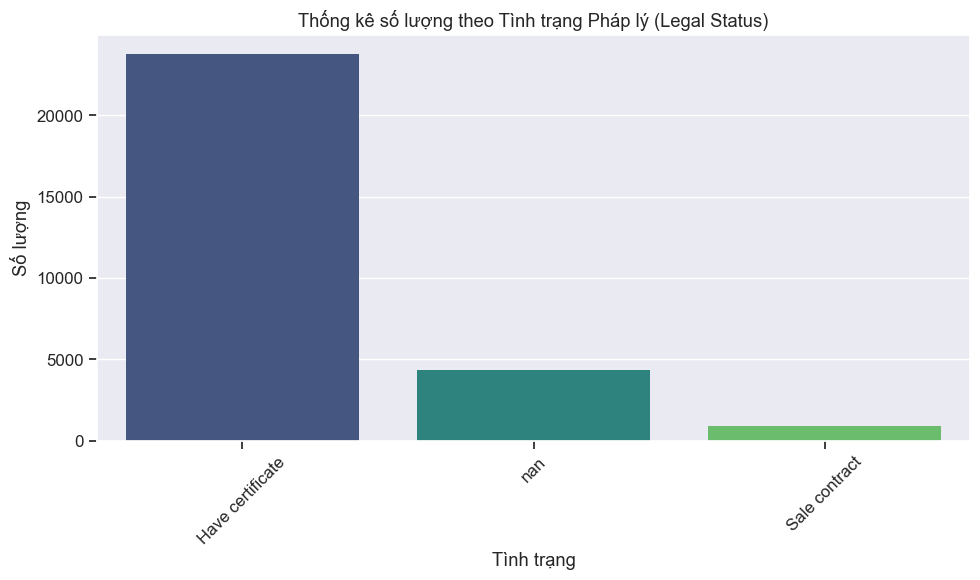

In [9]:
# =============================================================================
# KIỂM TRA SỐ LƯỢNG XUẤT HIỆN TRONG CỘT LEGAL STATUS
# =============================================================================
print("\n--- Thống kê số lượng trong cột legal_status ---")
if 'legal_status' in df.columns:
    # Tính toán số lượng xuất hiện (bao gồm cả giá trị NaN nếu có)
    legal_counts = df['legal_status'].value_counts(dropna=False)
    print(legal_counts)
    
    # Vẽ biểu đồ trực quan (nếu cần)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=legal_counts.index.astype(str), y=legal_counts.values, palette='viridis')
    plt.title('Thống kê số lượng theo Tình trạng Pháp lý (Legal Status)')
    plt.xlabel('Tình trạng')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Lỗi: Không tìm thấy cột 'legal_status' trong dữ liệu.")